# 12 News EDA

This notebook is designed to understand the **news view itself** so it can support three downstream purposes:

1. **Snorkel labeling functions**  
2. **Imputation decisions**  
3. **Feature engineering / modeling decisions**

 
It focuses on understanding the variables, missingness structure, distributional behavior, and whether features are suitable for:
- interpretable weak rules
- imputation
- later modeling

## Imports and project path setup

In [13]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:", src_path)

project_root: /Users/Thomas/Desktop/Master Thesis
src_path: /Users/Thomas/Desktop/Master Thesis/src


In [14]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from master_thesis.data_utils import load_raw, save_processed

## Load news data

Update the filename below if needed.

In [15]:
df_news = load_raw("news.csv", low_memory=False)

print("Shape:", df_news.shape)
display(df_news.head())

Shape: (835, 11)


,supplier_number,Join_Year,article_count,negative_count,positive_count,neutral_count,avg_sentiment_score,avg_relevance_score,max_relevance_score,negative_ratio,has_high_relevance_negative_news
0,1011795,2017,1,0,1,0,1.000,3.0000,3.0,0.0,0
1,1011795,2019,2,0,2,0,1.000,3.5000,4.0,0.0,0
2,1011795,2020,3,0,3,0,1.000,3.5000,4.0,0.0,0
3,1011795,2022,8,0,7,1,0.875,3.1875,4.0,0.0,0
4,1011795,2023,8,0,7,1,0.875,3.0625,3.5,0.0,0


## Standardize key column names

This makes the EDA more consistent with later feature engineering.

In [16]:
df_news = df_news.copy()

rename_map = {
    "Join_Year": "join_year",
    "Article_count": "article_count",
    "Negative_count": "negative_count",
    "Positive_count": "positive_count",
    "Neutral_count": "neutral_count",
    "Avg_sentiment_score": "avg_sentiment_score",
    "Avg_relevance_score": "avg_relevance_score",
    "Max_relevance_score": "max_relevance_score",
    "Negative_ratio": "negative_ratio",
    "Has_high_relevance_negative_news": "has_high_relevance_negative_news",
}

rename_map = {k: v for k, v in rename_map.items() if k in df_news.columns}
df_news = df_news.rename(columns=rename_map)

if "supplier_number" in df_news.columns:
    df_news["supplier_number"] = (
        df_news["supplier_number"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
    )

if "join_year" in df_news.columns:
    df_news["join_year"] = pd.to_numeric(df_news["join_year"], errors="coerce").astype("Int64")

print("Shape:", df_news.shape)
print("Columns:")
print(df_news.columns.tolist())

Shape: (835, 11)
Columns:
['supplier_number', 'join_year', 'article_count', 'negative_count', 'positive_count', 'neutral_count', 'avg_sentiment_score', 'avg_relevance_score', 'max_relevance_score', 'negative_ratio', 'has_high_relevance_negative_news']


## Basic structure overview

In [17]:
df_structure = pd.DataFrame({
    "feature": df_news.columns,
    "dtype": df_news.dtypes.astype(str).values,
    "missing_pct": df_news.isna().mean().values * 100,
    "n_unique": df_news.nunique(dropna=True).values,
}).sort_values(["missing_pct", "n_unique"], ascending=[False, True]).reset_index(drop=True)

display(df_structure)
print("Total features:", len(df_structure))

,feature,dtype,missing_pct,n_unique
0,has_high_relevance_negative_news,int64,0.0,2
1,join_year,Int64,0.0,12
2,max_relevance_score,float64,0.0,14
3,negative_count,int64,0.0,21
4,neutral_count,int64,0.0,26
5,positive_count,int64,0.0,31
6,article_count,int64,0.0,52
7,negative_ratio,float64,0.0,74
8,avg_sentiment_score,float64,0.0,102
9,avg_relevance_score,float64,0.0,206


Total features: 11


## Candidate news columns

This separates likely numeric news variables from identifiers / descriptive text.

In [18]:
id_like_cols = [
    c for c in df_news.columns
    if c in {"supplier_number", "join_year", "company_name", "news_company_name"}
    or "company_name" in c.lower()
    or "supplier_number" in c.lower()
]

numeric_candidate_cols = df_news.select_dtypes(include=["number"]).columns.tolist()
numeric_candidate_cols = [c for c in numeric_candidate_cols if c not in id_like_cols]

categorical_candidate_cols = [
    c for c in df_news.columns
    if c not in numeric_candidate_cols and c not in id_like_cols
]

print("Numeric candidate cols:", len(numeric_candidate_cols))
print("Categorical candidate cols:", len(categorical_candidate_cols))
print("ID-like cols:", id_like_cols)

Numeric candidate cols: 9
Categorical candidate cols: 0
ID-like cols: ['supplier_number', 'join_year']


## Missingness overview

This is critical for both imputation and deciding whether a feature is usable at all.

In [19]:
df_missing = pd.DataFrame({
    "feature": df_news.columns,
    "missing_pct": df_news.isna().mean().values * 100,
    "n_missing": df_news.isna().sum().values,
    "dtype": df_news.dtypes.astype(str).values,
}).sort_values("missing_pct", ascending=False).reset_index(drop=True)

display(df_missing)

,feature,missing_pct,n_missing,dtype
0,supplier_number,0.0,0,str
1,join_year,0.0,0,Int64
2,article_count,0.0,0,int64
3,negative_count,0.0,0,int64
4,positive_count,0.0,0,int64
5,neutral_count,0.0,0,int64
6,avg_sentiment_score,0.0,0,float64
7,avg_relevance_score,0.0,0,float64
8,max_relevance_score,0.0,0,float64
9,negative_ratio,0.0,0,float64


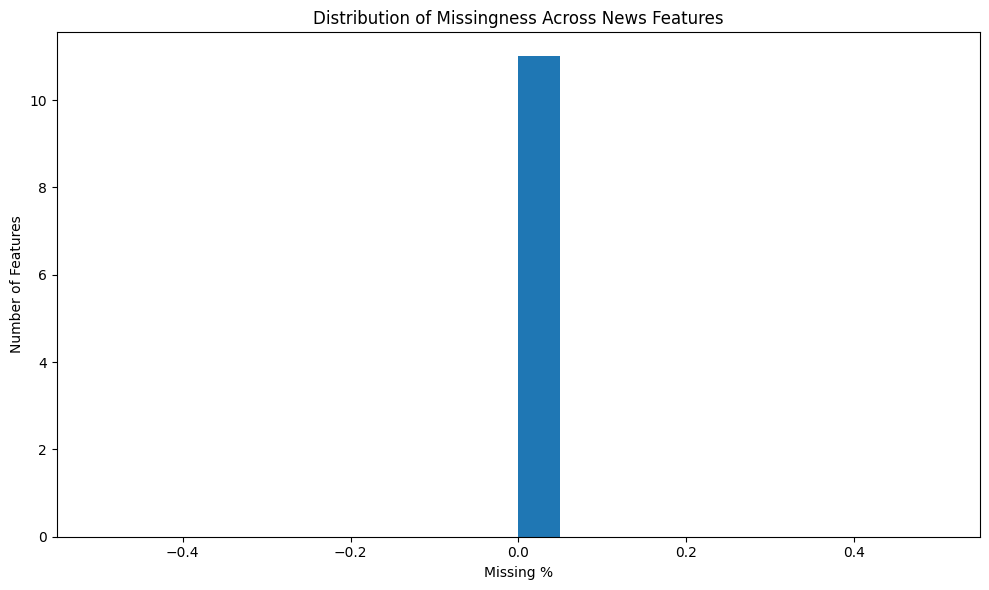

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_missing["missing_pct"], bins=20)
ax.set_title("Distribution of Missingness Across News Features")
ax.set_xlabel("Missing %")
ax.set_ylabel("Number of Features")
plt.tight_layout()
plt.show()

## Missingness buckets

This helps determine:
- which variables could be imputed
- which variables are too sparse
- which variables might be better summarized

In [21]:
def missing_bucket(x):
    if x == 0:
        return "0%"
    elif x <= 5:
        return "0-5%"
    elif x <= 20:
        return "5-20%"
    elif x <= 50:
        return "20-50%"
    elif x <= 80:
        return "50-80%"
    else:
        return "80%+"

df_missing["missing_bucket"] = df_missing["missing_pct"].apply(missing_bucket)

df_missing_bucket_summary = (
    df_missing.groupby("missing_bucket")
    .size()
    .reset_index(name="n_features")
)

display(df_missing_bucket_summary)

,missing_bucket,n_features
0,0%,11


## Numeric distribution screening

For numeric candidates we compute compact summary statistics.
This is useful for:
- spotting skewness / outliers
- identifying threshold candidates for Snorkel
- assessing whether median imputation is sensible

In [22]:
numeric_summary_rows = []

for col in numeric_candidate_cols:
    s = pd.to_numeric(df_news[col], errors="coerce")
    non_missing = s.dropna()

    if len(non_missing) == 0:
        continue

    numeric_summary_rows.append({
        "feature": col,
        "missing_pct": s.isna().mean() * 100,
        "n_non_missing": non_missing.shape[0],
        "mean": non_missing.mean(),
        "median": non_missing.median(),
        "std": non_missing.std(),
        "min": non_missing.min(),
        "p01": non_missing.quantile(0.01),
        "p05": non_missing.quantile(0.05),
        "p25": non_missing.quantile(0.25),
        "p50": non_missing.quantile(0.50),
        "p75": non_missing.quantile(0.75),
        "p95": non_missing.quantile(0.95),
        "p99": non_missing.quantile(0.99),
        "max": non_missing.max(),
    })

df_numeric_summary = pd.DataFrame(numeric_summary_rows).sort_values("missing_pct", ascending=False)
display(df_numeric_summary)

,feature,missing_pct,n_non_missing,mean,median,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,article_count,0.0,835,5.883832,2.0,10.184611,1.0,1.0,1.0,1.000000,2.0,5.0,26.000000,57.32,96.0
1,negative_count,0.0,835,0.737725,0.0,2.566049,0.0,0.0,0.0,0.000000,0.0,0.0,4.000000,13.66,33.0
2,positive_count,0.0,835,3.673054,2.0,5.808881,0.0,0.0,0.0,1.000000,2.0,4.0,17.000000,27.00,51.0
3,neutral_count,0.0,835,1.473054,0.0,3.762134,0.0,0.0,0.0,0.000000,0.0,1.0,6.300000,21.32,43.0
4,avg_sentiment_score,0.0,835,0.560833,0.8,0.562061,-1.0,-1.0,-1.0,0.186147,0.8,1.0,1.000000,1.00,1.0
5,avg_relevance_score,0.0,835,3.653618,3.5,0.575915,3.0,3.0,3.0,3.000000,3.5,4.0,4.835333,5.00,5.0
6,max_relevance_score,0.0,835,3.960359,4.0,0.752882,3.0,3.0,3.0,3.000000,4.0,5.0,5.000000,5.00,5.0
7,negative_ratio,0.0,835,0.104233,0.0,0.254986,0.0,0.0,0.0,0.000000,0.0,0.0,1.000000,1.00,1.0
8,has_high_relevance_negative_news,0.0,835,0.185629,0.0,0.389040,0.0,0.0,0.0,0.000000,0.0,0.0,1.000000,1.00,1.0


## Categorical screening

This is important for possible interpretable Snorkel rules and later feature engineering.

In [23]:
categorical_summary_rows = []

for col in categorical_candidate_cols:
    s = df_news[col].astype("string")
    top_values = s.value_counts(dropna=False).head(5)

    categorical_summary_rows.append({
        "feature": col,
        "missing_pct": s.isna().mean() * 100,
        "n_unique": s.nunique(dropna=True),
        "top_1": str(top_values.index[0]) if len(top_values) > 0 else None,
        "top_1_count": int(top_values.iloc[0]) if len(top_values) > 0 else None,
        "top_2": str(top_values.index[1]) if len(top_values) > 1 else None,
        "top_2_count": int(top_values.iloc[1]) if len(top_values) > 1 else None,
    })

if len(categorical_summary_rows) == 0:
    df_categorical_summary = pd.DataFrame(
        columns=[
            "feature",
            "missing_pct",
            "n_unique",
            "top_1",
            "top_1_count",
            "top_2",
            "top_2_count",
        ]
    )
else:
    df_categorical_summary = pd.DataFrame(categorical_summary_rows).sort_values(
        "missing_pct",
        ascending=False
    )

display(df_categorical_summary)

,feature,missing_pct,n_unique,top_1,top_1_count,top_2,top_2_count


## Snorkel-oriented EDA

The purpose here is to identify variables that can support simple, interpretable rules.
Typical good candidates are:
- negative article counts
- negative ratios
- relevance scores
- explicit high-relevance negative news flags

In [24]:
snorkel_candidate_cols = [
    c for c in [
        "article_count",
        "negative_count",
        "positive_count",
        "neutral_count",
        "avg_sentiment_score",
        "avg_relevance_score",
        "max_relevance_score",
        "negative_ratio",
        "has_high_relevance_negative_news",
    ]
    if c in df_news.columns
]

print("Snorkel candidate columns:")
print(snorkel_candidate_cols)

Snorkel candidate columns:
['article_count', 'negative_count', 'positive_count', 'neutral_count', 'avg_sentiment_score', 'avg_relevance_score', 'max_relevance_score', 'negative_ratio', 'has_high_relevance_negative_news']


In [25]:
for col in [c for c in ["has_high_relevance_negative_news"] if c in df_news.columns]:
    print(f"\n=== {col} ===")
    display(df_news[col].astype("string").value_counts(dropna=False).to_frame("count"))


=== has_high_relevance_negative_news ===


,count
has_high_relevance_negative_news,
0,680
1,155


In [26]:
df_snorkel_thresholds = df_numeric_summary[
    df_numeric_summary["feature"].isin(
        [c for c in snorkel_candidate_cols if c in df_numeric_summary["feature"].values]
    )
].copy()

display(df_snorkel_thresholds)

,feature,missing_pct,n_non_missing,mean,median,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,article_count,0.0,835,5.883832,2.0,10.184611,1.0,1.0,1.0,1.000000,2.0,5.0,26.000000,57.32,96.0
1,negative_count,0.0,835,0.737725,0.0,2.566049,0.0,0.0,0.0,0.000000,0.0,0.0,4.000000,13.66,33.0
2,positive_count,0.0,835,3.673054,2.0,5.808881,0.0,0.0,0.0,1.000000,2.0,4.0,17.000000,27.00,51.0
3,neutral_count,0.0,835,1.473054,0.0,3.762134,0.0,0.0,0.0,0.000000,0.0,1.0,6.300000,21.32,43.0
4,avg_sentiment_score,0.0,835,0.560833,0.8,0.562061,-1.0,-1.0,-1.0,0.186147,0.8,1.0,1.000000,1.00,1.0
5,avg_relevance_score,0.0,835,3.653618,3.5,0.575915,3.0,3.0,3.0,3.000000,3.5,4.0,4.835333,5.00,5.0
6,max_relevance_score,0.0,835,3.960359,4.0,0.752882,3.0,3.0,3.0,3.000000,4.0,5.0,5.000000,5.00,5.0
7,negative_ratio,0.0,835,0.104233,0.0,0.254986,0.0,0.0,0.0,0.000000,0.0,0.0,1.000000,1.00,1.0
8,has_high_relevance_negative_news,0.0,835,0.185629,0.0,0.389040,0.0,0.0,0.0,0.000000,0.0,0.0,1.000000,1.00,1.0


## Useful sanity relationships inside the news view

These checks help understand whether the aggregated news fields behave as expected.

In [27]:
check_cols = [c for c in ["article_count", "negative_count", "positive_count", "neutral_count"] if c in df_news.columns]

if set(["article_count", "negative_count", "positive_count", "neutral_count"]).issubset(df_news.columns):
    df_news["count_sum_check"] = (
        pd.to_numeric(df_news["negative_count"], errors="coerce").fillna(0)
        + pd.to_numeric(df_news["positive_count"], errors="coerce").fillna(0)
        + pd.to_numeric(df_news["neutral_count"], errors="coerce").fillna(0)
    )

    display(
        df_news[
            ["article_count", "negative_count", "positive_count", "neutral_count", "count_sum_check"]
        ].head(20)
    )

    print("Rows where article_count != negative+positive+neutral:",
          (pd.to_numeric(df_news["article_count"], errors="coerce") != df_news["count_sum_check"]).sum())

,article_count,negative_count,positive_count,neutral_count,count_sum_check
0,1,0,1,0,1
1,2,0,2,0,2
2,3,0,3,0,3
3,8,0,7,1,8
4,8,0,7,1,8
5,4,0,4,0,4
6,4,1,3,0,4
7,1,0,0,1,1
8,1,0,1,0,1
9,1,0,1,0,1


Rows where article_count != negative+positive+neutral: 0


In [28]:
if set(["negative_count", "article_count", "negative_ratio"]).issubset(df_news.columns):
    df_news["negative_ratio_recalc"] = (
        pd.to_numeric(df_news["negative_count"], errors="coerce")
        / pd.to_numeric(df_news["article_count"], errors="coerce").replace(0, np.nan)
    )

    display(
        df_news[
            ["article_count", "negative_count", "negative_ratio", "negative_ratio_recalc"]
        ].head(20)
    )

,article_count,negative_count,negative_ratio,negative_ratio_recalc
0,1,0,0.000000,0.000000
1,2,0,0.000000,0.000000
2,3,0,0.000000,0.000000
3,8,0,0.000000,0.000000
4,8,0,0.000000,0.000000
5,4,0,0.000000,0.000000
6,4,1,0.250000,0.250000
7,1,0,0.000000,0.000000
8,1,0,0.000000,0.000000
9,1,0,0.000000,0.000000


## Imputation-oriented EDA

This section is not about fitting imputation yet.
It is about deciding whether imputation is even reasonable.

In [29]:
df_imputation_candidates = df_structure.copy()

def imputation_recommendation(row):
    missing_pct = row["missing_pct"]
    dtype = row["dtype"]
    n_unique = row["n_unique"]

    if missing_pct == 0:
        return "no imputation needed"
    if missing_pct > 85:
        return "too sparse; prefer missing flag / view indicator / summary"
    if "float" in dtype or "int" in dtype:
        if missing_pct <= 50:
            return "median impute + missing flag"
        return "consider summary feature + missing flag"
    if "object" in dtype or "string" in dtype:
        return "missing category / explicit unknown"
    return "inspect manually"

df_imputation_candidates["imputation_recommendation"] = df_imputation_candidates.apply(
    imputation_recommendation,
    axis=1,
)

display(df_imputation_candidates.sort_values("missing_pct", ascending=False))

,feature,dtype,missing_pct,n_unique,imputation_recommendation
0,has_high_relevance_negative_news,int64,0.0,2,no imputation needed
1,join_year,Int64,0.0,12,no imputation needed
2,max_relevance_score,float64,0.0,14,no imputation needed
3,negative_count,int64,0.0,21,no imputation needed
4,neutral_count,int64,0.0,26,no imputation needed
5,positive_count,int64,0.0,31,no imputation needed
6,article_count,int64,0.0,52,no imputation needed
7,negative_ratio,float64,0.0,74,no imputation needed
8,avg_sentiment_score,float64,0.0,102,no imputation needed
9,avg_relevance_score,float64,0.0,206,no imputation needed


## Feature-engineering-oriented EDA

This section identifies raw news columns that may be better converted into more robust engineered signals.

In [30]:
feature_engineering_candidate_cols = [
    c for c in [
        "article_count",
        "negative_count",
        "positive_count",
        "neutral_count",
        "avg_sentiment_score",
        "avg_relevance_score",
        "max_relevance_score",
        "negative_ratio",
    ]
    if c in df_news.columns
]

print(feature_engineering_candidate_cols)

['article_count', 'negative_count', 'positive_count', 'neutral_count', 'avg_sentiment_score', 'avg_relevance_score', 'max_relevance_score', 'negative_ratio']


In [31]:
df_corr_input = df_news[feature_engineering_candidate_cols].copy()

for col in df_corr_input.columns:
    df_corr_input[col] = pd.to_numeric(df_corr_input[col], errors="coerce")

df_corr = df_corr_input.corr(numeric_only=True)

display(df_corr)

,article_count,negative_count,positive_count,neutral_count,avg_sentiment_score,avg_relevance_score,max_relevance_score,negative_ratio
article_count,1.000000,0.708736,0.895559,0.840949,-0.063755,0.246612,0.465829,0.047973
negative_count,0.708736,1.000000,0.439722,0.557625,-0.316656,0.174229,0.290721,0.350534
positive_count,0.895559,0.439722,1.000000,0.580441,0.140975,0.265836,0.475070,-0.080637
neutral_count,0.840949,0.557625,0.580441,1.000000,-0.174282,0.138314,0.329243,0.015287
avg_sentiment_score,-0.063755,-0.316656,0.140975,-0.174282,1.000000,-0.002119,-0.000670,-0.809926
avg_relevance_score,0.246612,0.174229,0.265836,0.138314,-0.002119,1.000000,0.879220,0.088392
max_relevance_score,0.465829,0.290721,0.475070,0.329243,-0.000670,0.879220,1.000000,0.065926
negative_ratio,0.047973,0.350534,-0.080637,0.015287,-0.809926,0.088392,0.065926,1.000000


In [32]:
high_corr_pairs = []

if not df_corr.empty:
    corr_matrix = df_corr.abs()
    for i, col1 in enumerate(corr_matrix.columns):
        for col2 in corr_matrix.columns[i+1:]:
            corr_val = corr_matrix.loc[col1, col2]
            if pd.notna(corr_val) and corr_val >= 0.80:
                high_corr_pairs.append({
                    "feature_1": col1,
                    "feature_2": col2,
                    "abs_corr": corr_val,
                })

df_high_corr_pairs = pd.DataFrame(high_corr_pairs).sort_values("abs_corr", ascending=False) if high_corr_pairs else pd.DataFrame(columns=["feature_1", "feature_2", "abs_corr"])
display(df_high_corr_pairs)

,feature_1,feature_2,abs_corr
0,article_count,positive_count,0.895559
3,avg_relevance_score,max_relevance_score,0.879220
1,article_count,neutral_count,0.840949
2,avg_sentiment_score,negative_ratio,0.809926


## Final decision table

This is the most important output of the notebook.

Each feature gets an initial recommendation for:
- Snorkel suitability
- imputation strategy
- feature engineering action

In [33]:
df_feature_decisions = df_structure.copy()

snorkel_candidate_set = set(snorkel_candidate_cols)

def snorkel_flag(feature):
    return "yes" if feature in snorkel_candidate_set else "no"

def feature_engineering_decision(row):
    feature = row["feature"]
    missing_pct = row["missing_pct"]

    if feature in snorkel_candidate_set and missing_pct <= 85:
        return "engineer interpretable flags / thresholds / summaries"
    if missing_pct > 85:
        return "drop raw / summarize if important"
    if missing_pct > 50:
        return "keep only if strong business relevance"
    return "keep or engineer"

df_feature_decisions["snorkel_candidate"] = df_feature_decisions["feature"].apply(snorkel_flag)
df_feature_decisions = df_feature_decisions.merge(
    df_imputation_candidates[["feature", "imputation_recommendation"]],
    on="feature",
    how="left",
)
df_feature_decisions["feature_engineering_decision"] = df_feature_decisions.apply(
    feature_engineering_decision,
    axis=1,
)

display(df_feature_decisions.sort_values(["snorkel_candidate", "missing_pct"], ascending=[False, False]))

,feature,dtype,missing_pct,n_unique,snorkel_candidate,imputation_recommendation,feature_engineering_decision
0,has_high_relevance_negative_news,int64,0.0,2,yes,no imputation needed,engineer interpretable flags / thresholds / su...
2,max_relevance_score,float64,0.0,14,yes,no imputation needed,engineer interpretable flags / thresholds / su...
3,negative_count,int64,0.0,21,yes,no imputation needed,engineer interpretable flags / thresholds / su...
4,neutral_count,int64,0.0,26,yes,no imputation needed,engineer interpretable flags / thresholds / su...
5,positive_count,int64,0.0,31,yes,no imputation needed,engineer interpretable flags / thresholds / su...
6,article_count,int64,0.0,52,yes,no imputation needed,engineer interpretable flags / thresholds / su...
7,negative_ratio,float64,0.0,74,yes,no imputation needed,engineer interpretable flags / thresholds / su...
8,avg_sentiment_score,float64,0.0,102,yes,no imputation needed,engineer interpretable flags / thresholds / su...
9,avg_relevance_score,float64,0.0,206,yes,no imputation needed,engineer interpretable flags / thresholds / su...
1,join_year,Int64,0.0,12,no,no imputation needed,keep or engineer


## Save EDA outputs

These outputs can be reused later in:
- Snorkel notebook
- feature engineering notebook
- modeling discussion

In [34]:
save_processed(df_structure, "news_eda_structure.csv")
save_processed(df_missing, "news_eda_missingness.csv")
save_processed(df_numeric_summary, "news_eda_numeric_summary.csv")
save_processed(df_categorical_summary, "news_eda_categorical_summary.csv")
save_processed(df_imputation_candidates, "news_eda_imputation_candidates.csv")
save_processed(df_feature_decisions, "news_eda_feature_decisions.csv")
save_processed(df_high_corr_pairs, "news_eda_high_corr_pairs.csv")

print("Saved news EDA outputs to Data/processed/")

Saved news EDA outputs to Data/processed/


## Short interpretation notes

Use this section to summarize:
- which news variables are strong LF candidates
- which variables are too sparse for direct use
- where missingness itself is informative
- which raw variables should later be converted into engineered news stress / sentiment signals